# TFG Crypto — Detección de regímenes de mercado (PCA + k-means + HMM)

Notebook **independiente** de la preparación de la LSTM y del RAG. Aquí no predecimos:
**clasificamos cada día en un régimen de mercado** (tranquilo / alcista / bajista-volátil...)
para entender la no-estacionariedad del mercado y, opcionalmente, generar una etiqueta de
régimen que pueda alimentar a la LSTM o al RAG.

Orden:
1. **Setup** y carga del mismo `df_merged.csv`.
2. **Variables de régimen** — pocas y limpias (volatilidad, tendencia, caída).
3. **PCA** — para visualizar en 2D (lo que ya conoces).
4. **k-means** — agrupa, pero SIN memoria temporal (parpadea).
5. **HMM** — agrupa CON memoria: los regímenes son pegajosos, no parpadea.
6. **Ventana 14d vs 30d** — el compromiso entre detectar rápido o detectar fiable.
7. **Aviso de lookahead** — versión descriptiva vs versión causal.

**Idea de fondo:** un régimen dura meses. Si ayer era bear, hoy lo más probable es que siga
siendo bear aunque los síntomas de hoy sean ambiguos. El HMM modela justo eso.

## 1. Setup y carga de datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from hmmlearn.hmm import GaussianHMM

pd.set_option("display.max_columns", None)

# Ajusta la ruta si tu CSV está en otro sitio (misma que en el notebook de preparación)
RUTA_CSV = "../data/csv/df_merged.csv"

df = pd.read_csv(RUTA_CSV, parse_dates=["date"], index_col="date").sort_index()
print(f"Shape: {df.shape}  |  Rango: {df.index.min().date()} -> {df.index.max().date()}")
df.head(3)

Shape: (3044, 19)  |  Rango: 2018-02-01 -> 2026-06-02


,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,FearGreed_Label,inflation,btc_mcap,eth_mcap,fed_rate
date,,,,,,,,,,,,,,,,,,,
2018-02-01,10237.299805,10288.799805,8812.280273,9170.540039,9.959400e+09,1119.369995,1161.349976,984.818970,1036.790039,5.261680e+09,0.334251,0.211308,0.454441,30.0,Fear,2.263469,1.703042e+11,1.076635e+11,1.42
2018-02-02,9142.280273,9142.280273,7796.490234,8830.750000,1.272690e+10,1035.770020,1035.770020,757.979980,915.784973,6.713290e+09,0.339622,0.221066,0.439312,15.0,Extreme Fear,2.263469,1.527442e+11,9.942376e+10,1.42
2018-02-03,8852.120117,9430.750000,8251.629883,9174.910156,7.263790e+09,919.210999,991.942993,847.690002,964.018982,3.243480e+09,0.350252,0.209758,0.439990,40.0,Fear,2.263469,1.487152e+11,8.906186e+10,1.42


## 2. Variables que definen un régimen

Un régimen NO necesita las 57 features. Se describe con pocas cosas:
- **Volatilidad** (14 y 30 días): cuánto se mueve el mercado.
- **Tendencia**: hacia dónde va (distancia a la media móvil de 50 días, retorno acumulado a 30d).
- **Caída desde máximos** (drawdown): cómo de hundido está respecto a su techo.

**Importante:** para el HMM/k-means usaremos un set SIN redundancia. Meter a la vez `vol_14d`
y `vol_30d` (que dicen casi lo mismo) confunde al HMM y lo hace parpadear. Calculamos las dos
para el análisis de la ventana (sección 6), pero al clasificar usamos solo `vol_30d`.

In [ ]:
eth = df["eth_close"]
ret = eth.pct_change() * 100                       # retorno % diario de ETH

reg = pd.DataFrame(index=df.index)
reg["ret"]          = ret
# --- Volatilidad (cómo de "loco" está el mercado) ---
reg["vol_30d"]      = ret.rolling(30).std()        # volatilidad estable (no la de 14d, para no parpadear)
# --- Dirección / tendencia (SUAVIZADA: ventanas largas para que el estado aguante una fase entera) ---
reg["cum_ret_60d"]  = ret.rolling(60).sum()        # tendencia a 60d (antes 30d): una subida = un solo color
reg["dist_sma200"]  = (eth / eth.rolling(200).mean() - 1) * 100   # ciclo de fondo (antes SMA50): alcista>0 / bajista<0
reg["drawdown"]     = (eth / eth.cummax() - 1) * 100             # fase del ciclo (0=máximos, -80=suelo del bear)
# --- Emoción (tu idea: distingue "caída con pánico" de "bear resignado / euforia") ---
reg["fg"]           = df["fear_greed"]      # Fear & Greed escalado (0=pánico, 1=euforia)
reg["precio"]       = eth

reg = reg.dropna().copy()
print(f"Días con datos completos: {len(reg)}  ({reg.index.min().date()} -> {reg.index.max().date()})")

# Variables que entran a la clasificación.
# Más peso a DIRECCIÓN (cum_ret_60d, dist_sma200, drawdown) + EMOCIÓN (fg) que a volatilidad,
# para que los 3 estados sean: EUFORIA / CAÍDA / BEAR PROFUNDO, y no "movido vs tranquilo".
VARS_REGIMEN = ["vol_30d", "cum_ret_60d", "dist_sma200", "drawdown", "fg"]
print(f"Variables para clasificar regímenes: {VARS_REGIMEN}")
reg[VARS_REGIMEN].describe().T

Días con datos completos: 2845  (2018-08-19 -> 2026-06-02)
Variables para clasificar regímenes: ['vol_30d', 'cum_ret_60d', 'dist_sma200', 'drawdown', 'fg']


,count,mean,std,min,25%,50%,75%,max
vol_30d,2845.0,4.007070,1.534747,0.805873,2.976903,3.754394,4.787101,11.023952
cum_ret_60d,2845.0,9.125218,36.250205,-105.073019,-16.174212,8.682032,33.285564,133.286476
dist_sma200,2845.0,9.590103,44.328041,-72.556079,-19.156820,4.876249,30.247984,193.858651
drawdown,2845.0,-53.599603,24.275821,-91.868335,-74.388713,-58.389006,-36.046835,0.000000
fg,2845.0,46.719508,22.223470,5.000000,27.000000,47.000000,66.000000,95.000000


## 3. PCA: ver los datos en 2D

Estandarizamos (media 0, desviación 1) y proyectamos a 2 dimensiones para poder pintar.
Es exactamente lo que hiciste con los clientes: PCA no clasifica, solo permite *ver* si hay
estructura. Si los puntos forman nubes distinguibles, hay regímenes que separar.

Varianza explicada por las 2 componentes: [0.559 0.217]  (suma 77.6%)


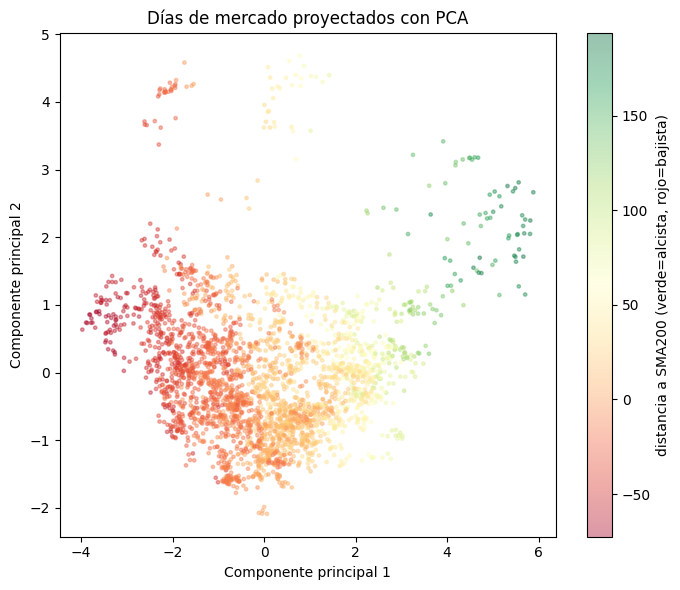

In [ ]:
scaler_hmm = StandardScaler().fit(reg[VARS_REGIMEN].values)
X = scaler_hmm.transform(reg[VARS_REGIMEN].values)

pca = PCA(n_components=2).fit(X)
Xp = pca.transform(X)
print(f"Varianza explicada por las 2 componentes: {pca.explained_variance_ratio_.round(3)}  "
      f"(suma {pca.explained_variance_ratio_.sum():.1%})")

plt.figure(figsize=(7, 6))
plt.scatter(Xp[:, 0], Xp[:, 1], s=6, alpha=0.4, c=reg["dist_sma200"].values, cmap="RdYlGn")
plt.colorbar(label="distancia a SMA200 (verde=alcista, rojo=bajista)")
plt.xlabel("Componente principal 1"); plt.ylabel("Componente principal 2")
plt.title("Días de mercado proyectados con PCA"); plt.tight_layout(); plt.show()

## 4. k-means: agrupa, pero SIN memoria temporal

Tu método conocido. Agrupa los días en k clusters por parecido. Probamos k=3.
**El problema que verás:** k-means trata cada día por separado, no sabe que el tiempo existe.
Por eso, al pintar el precio coloreado por cluster, verás que **parpadea** (whipsaw): cambia de
régimen de un día para otro, lo cual no tiene sentido para algo que dura meses.

In [ ]:
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)
reg["cluster_km"] = km.labels_

# Interpretar cada cluster por sus medias reales
print("── Media de cada variable por cluster (k-means) ──")
print(reg.groupby("cluster_km")[VARS_REGIMEN].mean().round(2).to_string())

cambios_km = int((np.diff(reg["cluster_km"].values) != 0).sum())
print(f"\nCambios de etiqueta a lo largo del tiempo (k-means): {cambios_km}")

── Media de cada variable por cluster (k-means) ──
            vol_30d  cum_ret_60d  dist_sma200  drawdown     fg
cluster_km                                                    
0              4.90       -25.06       -28.00    -67.51  24.35
1              4.53        51.43        71.00    -25.53  70.69
2              3.14        13.77         7.83    -56.71  51.47

Cambios de etiqueta a lo largo del tiempo (k-means): 133


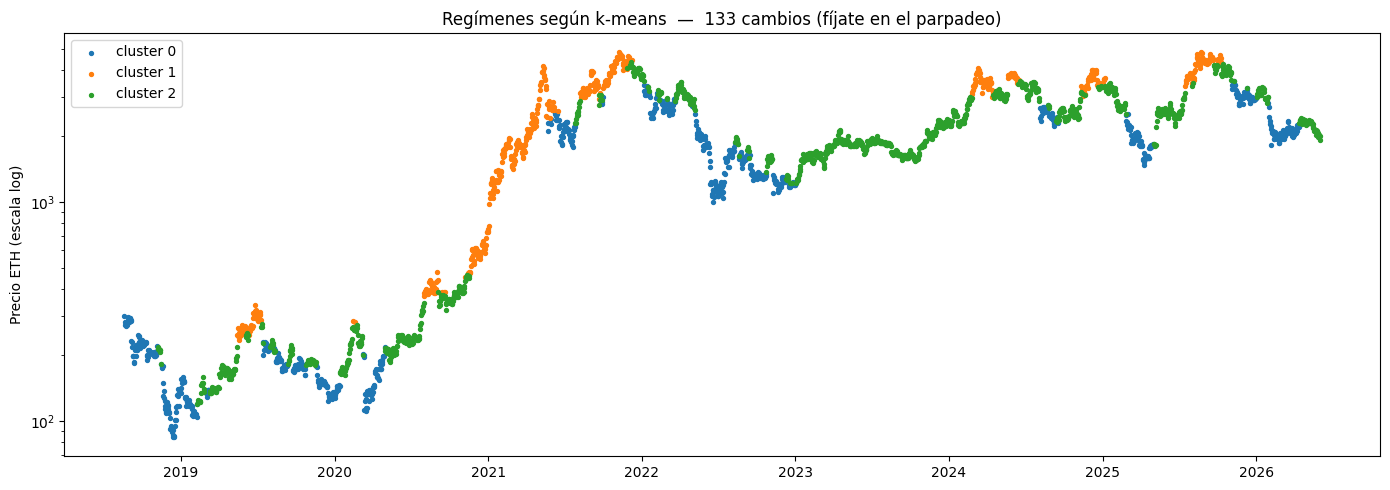

In [ ]:
# Mapeo de etiquetas
nombres_regimen = {
    0: "Momento bajista",
    1: "Momento alcista",
    2: "Acumulación"
}

fig, ax = plt.subplots(figsize=(14, 5))

for c in sorted(reg["cluster_km"].unique()):
    m = reg["cluster_km"] == c

    ax.scatter(
        reg.index[m],
        reg["precio"][m],
        s=8,
        label=nombres_regimen[c]
    )

ax.set_yscale("log")
ax.set_ylabel("Precio Ethereum")

ax.set_title(
    f"Regímenes según k-means — {cambios_km} cambios"
)

ax.legend()
plt.tight_layout()
plt.show()

## 5. HMM: agrupa CON memoria — los regímenes son pegajosos

El Hidden Markov Model aprende, además de cómo es cada régimen, la **probabilidad de quedarse
en el mismo régimen al día siguiente** (la diagonal de la matriz de transición). Como aprende
que cambiar es raro, no parpadea: da bloques limpios y continuos, y marca de forma natural
dónde empieza y acaba cada régimen.

**Truco de robustez:** el HMM puede caer en soluciones malas según la inicialización. Probamos
varias semillas y nos quedamos con la de mayor verosimilitud (`score`). Esto es clave: sin ello
el HMM puede parpadear incluso más que el k-means.

In [6]:
def ajustar_mejor_hmm(X, n_estados=3, semillas=range(12)):
    """Prueba varias semillas y devuelve el HMM con mayor verosimilitud."""
    mejor = None
    for s in semillas:
        m = GaussianHMM(n_components=n_estados, covariance_type="full",
                        n_iter=300, random_state=s, tol=1e-4)
        try:
            m.fit(X)
            sc = m.score(X)
        except Exception:
            continue
        if mejor is None or sc > mejor[0]:
            mejor = (sc, m)
    return mejor[1]

hmm = ajustar_mejor_hmm(X, n_estados=3)
reg["estado_hmm"] = hmm.predict(X)

cambios_hmm = int((np.diff(reg["estado_hmm"].values) != 0).sum())
print(f"Cambios de etiqueta (HMM): {cambios_hmm}   vs   k-means: {cambios_km}")
print(f"\nMatriz de transición (fila = estado de hoy, columna = estado de mañana):")
print(np.round(hmm.transmat_, 3))
print(f"\nPersistencia (prob. de quedarse en el mismo estado): {np.diag(hmm.transmat_).round(3)}")
print("Cuanto más cerca de 1, más pegajoso es el régimen.")

Cambios de etiqueta (HMM): 27   vs   k-means: 133

Matriz de transición (fila = estado de hoy, columna = estado de mañana):
[[0.996 0.002 0.002]
 [0.005 0.987 0.008]
 [0.    0.014 0.986]]

Persistencia (prob. de quedarse en el mismo estado): [0.996 0.987 0.986]
Cuanto más cerca de 1, más pegajoso es el régimen.


In [7]:
# Interpretar cada estado del HMM por sus medias reales
print("── Media de cada variable por estado (HMM) ──")
print(reg.groupby("estado_hmm")[VARS_REGIMEN].mean().round(2).to_string())
print()
print("Lectura esperada de los 3 estados:")
print("  EUFORIA / parabólica : cum_ret_60d alto, dist_sma200 muy positiva, fg alto (codicia).")
print("  CAÍDA / inicio bear  : cum_ret_60d girando a negativo, vol_30d alta, drawdown creciendo.")
print("  BEAR PROFUNDO        : drawdown muy negativo y sostenido, fg bajo (pánico/resignación).")
print("(Los números de estado 0/1/2 los asigna el HMM al azar; se identifican por estas medias.)")

── Media de cada variable por estado (HMM) ──
            vol_30d  cum_ret_60d  dist_sma200  drawdown     fg
estado_hmm                                                    
0              3.28        14.37        13.95    -70.35  50.56
1              4.74       -16.42       -22.76    -56.01  26.69
2              4.09        38.25        50.09    -23.49  69.99

Lectura esperada de los 3 estados:
  EUFORIA / parabólica : cum_ret_60d alto, dist_sma200 muy positiva, fg alto (codicia).
  CAÍDA / inicio bear  : cum_ret_60d girando a negativo, vol_30d alta, drawdown creciendo.
  BEAR PROFUNDO        : drawdown muy negativo y sostenido, fg bajo (pánico/resignación).
(Los números de estado 0/1/2 los asigna el HMM al azar; se identifican por estas medias.)


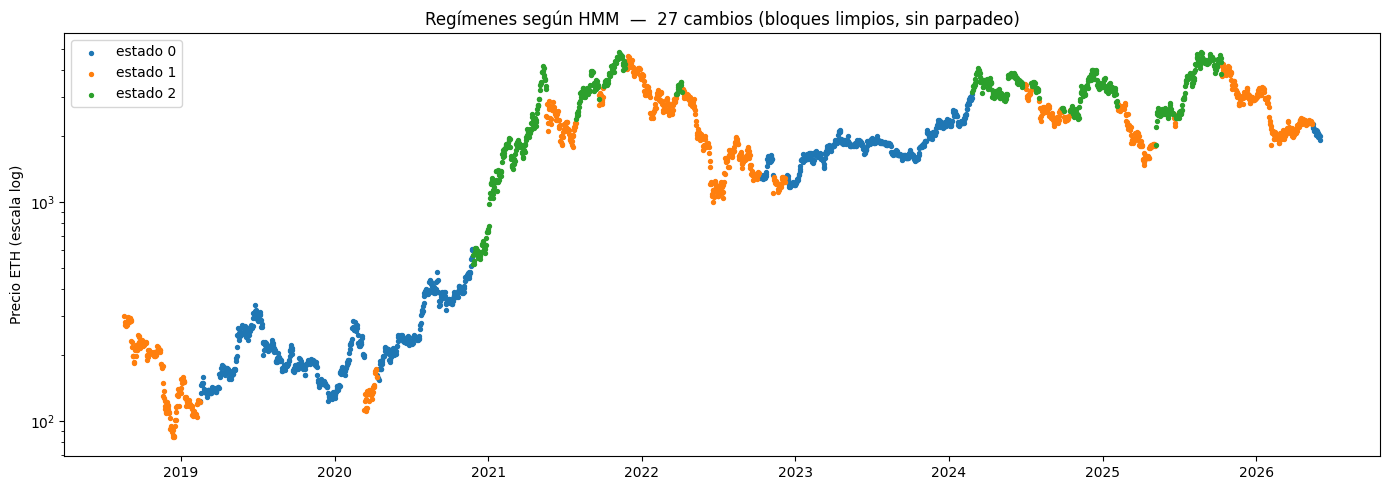

In [8]:
# El precio coloreado por el régimen del HMM: compáralo con el de k-means
fig, ax = plt.subplots(figsize=(14, 5))
for s in sorted(reg["estado_hmm"].unique()):
    m = reg["estado_hmm"] == s
    ax.scatter(reg.index[m], reg["precio"][m], s=8, label=f"estado {s}")
ax.set_yscale("log"); ax.set_ylabel("Precio ETH (escala log)")
ax.set_title(f"Regímenes según HMM  —  {cambios_hmm} cambios (bloques limpios, sin parpadeo)")
ax.legend(); plt.tight_layout(); plt.show()

## 6. La pregunta de la ventana: tendencia a 30d vs 60d

El problema que viste (una misma subida pintada de varios colores) viene de usar ventanas
cortas: con cum_ret a 30d, dentro de una subida larga hay correcciones que hacen que la
variable cambie de signo, y el HMM parte la subida en trozos.

- **30 días:** reacciona rápido, pero **parpadea** dentro de una fase (cada corrección la mueve).
- **60 días:** más **suave** → una subida parabólica entera se mantiene como un solo régimen.

Por eso pasamos a cum_ret_60d y a dist_sma200 (en vez de sma50): estados más pegajosos,
que aguantan toda una fase de mercado. La gráfica compara las dos ventanas.

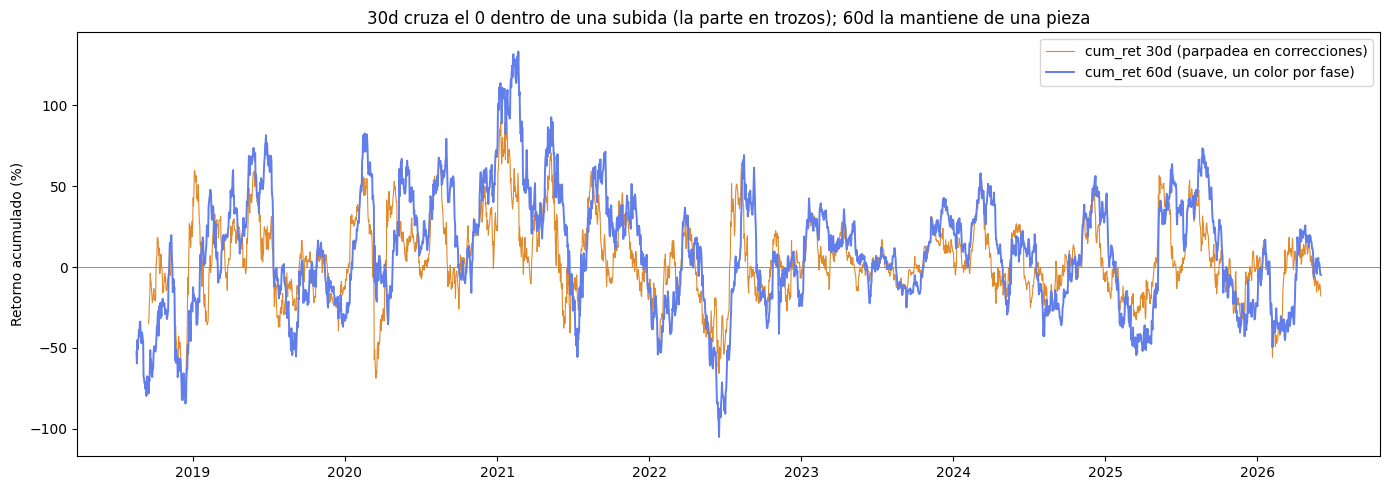

Veces que cruza el 0 (cambia de signo): 30d = 220  |  60d = 134
Menos cruces = menos parpadeo = regímenes más estables. Por eso elegimos 60d.


In [9]:
# Comparar la tendencia a 30d (lo que usábamos) vs 60d (lo nuevo, más suave)
ret = reg["ret"]
cum_30 = ret.rolling(30).sum()
fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(0, color="gray", lw=0.6)
ax.plot(reg.index, cum_30, lw=0.8, label="cum_ret 30d (parpadea en correcciones)", color="#E08A2B")
ax.plot(reg.index, reg["cum_ret_60d"], lw=1.4, label="cum_ret 60d (suave, un color por fase)", color="#627EEA")
ax.set_ylabel("Retorno acumulado (%)")
ax.set_title("30d cruza el 0 dentro de una subida (la parte en trozos); 60d la mantiene de una pieza")
ax.legend(); plt.tight_layout(); plt.show()

cruces_30 = int((np.diff(np.sign(cum_30.dropna().values)) != 0).sum())
cruces_60 = int((np.diff(np.sign(reg["cum_ret_60d"].dropna().values)) != 0).sum())
print(f"Veces que cruza el 0 (cambia de signo): 30d = {cruces_30}  |  60d = {cruces_60}")
print("Menos cruces = menos parpadeo = regímenes más estables. Por eso elegimos 60d.")

## 7. Aviso importante: lookahead (mirar el futuro sin querer)

Todo lo anterior ajusta el modelo con los **8 años enteros**. Eso significa que la etiqueta de
régimen del día *t* se calculó sabiendo lo que pasó *después*. Para **describir** la historia y
hacer estas gráficas, es correcto y útil.

**PERO** si quieres usar la etiqueta de régimen como una columna más para la LSTM, tiene que ser
**causal**: calculada usando solo el pasado de cada día. Si no, le estarías colando el futuro al
modelo y el resultado sería tramposo (parecería buenísimo y luego fallaría en real).

Abajo, una versión causal sencilla: ajustamos el HMM SOLO con el primer 70% (train) y con ese
modelo ya fijo etiquetamos el resto. Así la etiqueta de validación/test no usó su propio futuro
para entrenarse. (Nota: `predict` de hmmlearn aún suaviza dentro del tramo; una versión 100%
online día a día sería el siguiente refinamiento, pero esto ya evita la fuga gruesa.)

In [10]:
n = len(reg)
i_train = int(n * 0.70)
X_train = X[:i_train]

hmm_causal = ajustar_mejor_hmm(X_train, n_estados=3)        # ajustado SOLO con train
reg["estado_hmm_causal"] = hmm_causal.predict(X)            # etiqueta todo con el modelo de train

# ¿Cuánto se parece la versión causal a la descriptiva? (no tienen por qué coincidir los números de estado)
print("Distribución de estados (causal):")
print(reg["estado_hmm_causal"].value_counts().sort_index().to_string())
print("\nEsta columna 'estado_hmm_causal' es la que podrías pasar a la LSTM como feature de régimen,")
print("o al RAG para que diga 'estamos en régimen X, la señal cuantitativa es más/menos fiable'.")

Distribución de estados (causal):
estado_hmm_causal
0    1097
1     871
2     877

Esta columna 'estado_hmm_causal' es la que podrías pasar a la LSTM como feature de régimen,
o al RAG para que diga 'estamos en régimen X, la señal cuantitativa es más/menos fiable'.


## 8. Guardar resultado

Guardamos el dataframe con las etiquetas de régimen por día, por si quieres reutilizarlo.

In [11]:
salida = reg[["precio", "vol_30d", "cum_ret_60d", "dist_sma200", "drawdown", "fg",
              "cluster_km", "estado_hmm", "estado_hmm_causal"]].copy()
salida.to_csv("../data/csv/regimenes.csv")
print(f"✓ Guardado en ../data/csv/regimenes.csv  ({len(salida)} filas)")
print("La columna 'estado_hmm_causal' (entrenada solo con train) es la que se integra en la LSTM.")
salida.tail()

✓ Guardado en ../data/csv/regimenes.csv  (2845 filas)
La columna 'estado_hmm_causal' (entrenada solo con train) es la que se integra en la LSTM.


,precio,vol_30d,cum_ret_60d,dist_sma200,drawdown,fg,cluster_km,estado_hmm,estado_hmm_causal
date,,,,,,,,,
2026-05-29,2000.340729,1.977346,2.680152,-20.460273,-58.596639,23.0,2,0,2
2026-05-30,2017.673674,1.980069,1.497429,-19.547511,-58.237879,23.0,2,0,2
2026-05-31,2015.840214,1.978788,-2.598363,-19.396080,-58.275828,28.0,2,0,2
2026-06-01,2003.971930,1.906497,-4.811024,-19.673301,-58.521480,29.0,2,0,2
2026-06-02,1926.351414,2.000602,-4.843059,-22.601978,-60.128081,23.0,2,0,2


In [16]:
import pandas as pd

# Cargar los regímenes ya calculados (ajusta ruta/nombre)
reg = pd.read_csv("../data/csv/regimenes.csv", parse_dates=["date"], index_col="date")

# La columna de estado: usa la que tengas (estado_hmm o estado_hmm_causal)
COL_ESTADO = "estado_hmm"   # o "estado_hmm_causal"

# Mapeo número -> nombre (ajústalo al que te salió al guardar el pkl)
NOMBRES = {0: "Alcista", 1: "Acumulacion", 2: "Bajista"}   # ⚠️ pon TU mapeo real

# --- Detectar tramos: un tramo nuevo empieza cuando el estado cambia ---
estados = reg[COL_ESTADO].values
cambio = (reg[COL_ESTADO] != reg[COL_ESTADO].shift()).cumsum()

tramos = []
for _, g in reg.groupby(cambio):
    estado = int(g[COL_ESTADO].iloc[0])
    tramos.append({
        "inicio": g.index[0].date(),
        "fin": g.index[-1].date(),
        "dias": len(g),
        "estado": estado,
        "nombre": NOMBRES.get(estado, f"Estado {estado}"),
    })

tabla = pd.DataFrame(tramos)

print(f"Total de tramos (cambios de régimen): {len(tabla)}\n")
print("="*75)
print(f"{'#':>3}  {'Inicio':<12} {'Fin':<12} {'Días':>5}  {'Régimen'}")
print("="*75)
for i, r in tabla.iterrows():
    print(f"{i+1:>3}  {str(r['inicio']):<12} {str(r['fin']):<12} {r['dias']:>5}  {r['nombre']}")

# Resumen: cuánto tiempo total en cada régimen
print("\n" + "="*40)
print("Tiempo total en cada régimen:")
resumen = tabla.groupby("nombre")["dias"].agg(["sum", "count"])
resumen.columns = ["días_totales", "nº_tramos"]
resumen["% del tiempo"] = (resumen["días_totales"] / resumen["días_totales"].sum() * 100).round(1)
print(resumen.to_string())

Total de tramos (cambios de régimen): 28

  #  Inicio       Fin           Días  Régimen
  1  2018-08-19   2019-02-14     180  Acumulacion
  2  2019-02-15   2020-03-11     391  Alcista
  3  2020-03-12   2020-04-11      31  Acumulacion
  4  2020-04-12   2020-11-24     227  Alcista
  5  2020-11-25   2021-05-18     175  Bajista
  6  2021-05-19   2021-07-28      71  Acumulacion
  7  2021-07-29   2021-09-20      54  Bajista
  8  2021-09-21   2021-10-01      11  Acumulacion
  9  2021-10-02   2021-11-22      52  Bajista
 10  2021-11-23   2022-03-23     121  Acumulacion
 11  2022-03-24   2022-04-06      14  Bajista
 12  2022-04-07   2022-10-06     183  Acumulacion
 13  2022-10-07   2022-11-08      33  Alcista
 14  2022-11-09   2022-12-08      30  Acumulacion
 15  2022-12-09   2024-02-25     444  Alcista
 16  2024-02-26   2024-06-24     120  Bajista
 17  2024-06-25   2024-07-14      20  Acumulacion
 18  2024-07-15   2024-08-02      19  Bajista
 19  2024-08-03   2024-09-26      55  Acumulacion
 2

---
### Cómo leer los resultados

1. **Compara los dos mapas de color** (sección 4 vs 5). Si el del HMM sale en bloques limpios y
   el del k-means parpadea, has demostrado por qué la memoria temporal importa.
2. **Mira la persistencia** (diagonal de la matriz). Si está cerca de 1, el HMM ha aprendido solo
   que los regímenes duran. Ese número es citable en la defensa.
3. **Interpreta los estados** con las tablas de medias: ponles nombre (lateral, alcista, crash...).
4. La columna `estado_hmm_causal` es la candidata a feature de régimen para la LSTM.

**No esperes que esto solo dispare el acierto direccional al 55%.** Es un estudio que explica la
no-estacionariedad del mercado y aporta una herramienta; si además mueve la LSTM, mejor, pero su
valor no depende de eso.

In [12]:
# === Caracterización estadística de cada régimen (para documentar) ===
# Variables a perfilar: las que entraron al HMM + otras interpretables (retorno diario, precio)
vars_perfil = VARS_REGIMEN + ["ret", "precio"]
vars_perfil = list(dict.fromkeys(vars_perfil))  # quita duplicados manteniendo orden

print("="*70)
print("  PERFIL ESTADÍSTICO DE CADA RÉGIMEN (estado_hmm)")
print("="*70)

# Tabla resumen: media de cada variable por estado (la foto rápida)
print("\n── Medias por estado ──")
print(reg.groupby("estado_hmm")[vars_perfil].mean().round(3).to_string())

# Para cada variable, el detalle completo (media, std, min, max, mediana) por estado
for v in vars_perfil:
    print(f"\n── {v} ──")
    tabla = reg.groupby("estado_hmm")[v].agg(
        media="mean", desv="std", minimo="min", q25=lambda x: x.quantile(.25),
        mediana="median", q75=lambda x: x.quantile(.75), maximo="max"
    ).round(3)
    print(tabla.to_string())

# Cuántos días y qué % del tiempo pasa el mercado en cada régimen
print("\n── Frecuencia de cada régimen ──")
frec = reg["estado_hmm"].value_counts().sort_index()
for estado, n in frec.items():
    print(f"  Estado {estado}: {n:>4} días  ({n/len(reg)*100:5.1f}% del tiempo)")

  PERFIL ESTADÍSTICO DE CADA RÉGIMEN (estado_hmm)

── Medias por estado ──
            vol_30d  cum_ret_60d  dist_sma200  drawdown      fg    ret    precio
estado_hmm                                                                      
0             3.276       14.373       13.945   -70.349  50.560  0.288   948.319
1             4.740      -16.423      -22.756   -56.005  26.687 -0.231  1965.259
2             4.093       38.246       50.092   -23.494  69.989  0.527  3006.920

── vol_30d ──
            media   desv  minimo    q25  mediana    q75  maximo
estado_hmm                                                     
0           3.276  1.089   0.806  2.501    3.173  3.849   6.437
1           4.740  1.781   1.745  3.560    4.462  5.514  11.024
2           4.093  1.173   1.773  3.308    4.037  4.664   8.333

── cum_ret_60d ──


             media    desv   minimo     q25  mediana     q75   maximo
estado_hmm                                                           
0           14.373  26.871  -55.293  -4.717   12.664  30.220   82.672
1          -16.423  30.778 -105.073 -36.010  -19.045   3.393   69.863
2           38.246  30.734  -34.568  17.991   36.633  52.241  133.286

── dist_sma200 ──
             media    desv  minimo     q25  mediana     q75   maximo
estado_hmm                                                          
0           13.945  28.100 -40.112  -9.270   13.956  27.307  103.119
1          -22.756  25.918 -72.556 -40.974  -23.964 -12.316   79.125
2           50.092  50.245 -33.038  12.356   38.139  69.609  193.859

── drawdown ──
             media    desv  minimo     q25  mediana     q75  maximo
estado_hmm                                                         
0          -70.349  11.207 -88.223 -80.771  -69.079 -61.907 -35.315
1          -56.005  20.286 -91.868 -73.377  -54.980 -40.620  -3.75

In [13]:
# === Guardar el modelo HMM para producción (scaler + pca + hmm + nombres) ===
import joblib
from pathlib import Path

# Mapear cada estado a su nombre POR CARACTERÍSTICAS (no por número, que es arbitrario):
# el de menor cum_ret_60d medio = Bajista; el mayor = Alcista; el del medio = Acumulacion.
medias = reg.groupby("estado_hmm")["cum_ret_60d"].mean().sort_values()
nombres = {int(medias.index[0]): "Bajista",
           int(medias.index[1]): "Acumulacion",
           int(medias.index[2]): "Alcista"}
print("Mapeo de estados -> nombre:", nombres)

Path("../models").mkdir(exist_ok=True)
joblib.dump({
    "hmm": hmm,                    # HMM entrenado con TODOS los datos (para producción)
    "scaler": scaler_hmm,          # StandardScaler ya ajustado
    "pca": pca,                    # PCA ya ajustado
    "vars_regimen": VARS_REGIMEN,  # lista de columnas de entrada
    "nombres": nombres,            # {estado: nombre} por características
}, "../models/hmm_final.pkl")
print("✓ Modelo guardado en ../models/hmm_final.pkl")
print("  Contiene: hmm, scaler, pca, vars_regimen, nombres")

Mapeo de estados -> nombre: {1: 'Bajista', 0: 'Acumulacion', 2: 'Alcista'}
✓ Modelo guardado en ../models/hmm_final.pkl
  Contiene: hmm, scaler, pca, vars_regimen, nombres


In [17]:
import joblib
d = joblib.load("../models/hmm_final.pkl")   # ajusta la ruta a donde lo guardaste
print("Mapeo guardado en el pkl:", d["nombres"])
print("Variables:", d["vars_regimen"])
print("Claves:", list(d.keys()))

Mapeo guardado en el pkl: {1: 'Bajista', 0: 'Acumulacion', 2: 'Alcista'}
Variables: ['vol_30d', 'cum_ret_60d', 'dist_sma200', 'drawdown', 'fg']
Claves: ['hmm', 'scaler', 'pca', 'vars_regimen', 'nombres']
